In [4]:
import numpy as np
from scipy.stats import norm

def bs_price(S, K, T, r, sigma, option="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option == "call":
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option must be 'call' or 'put'")

In [5]:
# Test 1
price = bs_price(100, 100, 1, 0.05, 0.2, "call")
print(price)  # approximately 10.4506
assert abs(price - 10.4506) < 1e-4

# Test 2
S, K, T, r, sigma = 100, 110, 0.5, 0.03, 0.25
call = bs_price(S, K, T, r, sigma, "call")
put = bs_price(S, K, T, r, sigma, "put")
assert abs((call - put) - (S - K * np.exp(-r * T))) < 1e-10

print("All passed!")

10.450583572185565
All passed!


In [6]:
import numpy as np

def binomial_price(S, K, T, r, sigma, n, option="call", american=False):
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)
    discount = np.exp(-r * dt)

    # Grow j times, jump (n-j) times，j = 0..n
    j = np.arange(n + 1)
    ST = S * (u ** j) * (d ** (n - j))

    # Option Value on Expiration Date
    if option == "call":
        values = np.maximum(ST - K, 0)
    else:
        values = np.maximum(K - ST, 0)

    # Discount
    for step in range(n, 0, -1):
        values = discount * (p * values[1:] + (1 - p) * values[:-1])
        if american:
            # American option should evaluate whether to exercise at every step
            j = np.arange(step)
            ST_step = S * (u ** j) * (d ** (step - 1 - j))
            if option == "call":
                exercise = np.maximum(ST_step - K, 0)
            else:
                exercise = np.maximum(K - ST_step, 0)
            values = np.maximum(values, exercise)

    return values[0]

In [7]:
price_tree = binomial_price(100, 100, 1, 0.05, 0.2, n=500, option="call")
price_bs = bs_price(100, 100, 1, 0.05, 0.2, "call")
print(price_tree, price_bs)

10.44658513644654 10.450583572185565


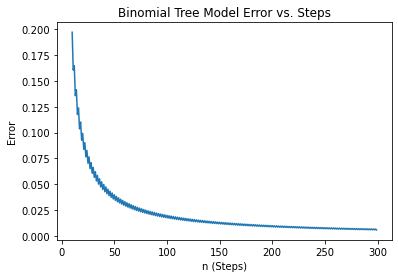

In [8]:
import matplotlib.pyplot as plt

ns = np.arange(10, 300)
errors = [abs(binomial_price(100, 100, 1, 0.05, 0.2, n) - price_bs) for n in ns]

plt.plot(ns, errors)
plt.xlabel("n (Steps)")
plt.ylabel("Error")
plt.title("Binomial Tree Model Error vs. Steps")
plt.show()

In [9]:
def mc_price(S, K, T, r, sigma, n_paths, option="call", seed=None, antithetic=False):
    rng = np.random.default_rng(seed)

    if antithetic:
        # Antithetic Sampling
        half = n_paths // 2
        Z = rng.standard_normal(half)
        Z = np.concatenate([Z, -Z])
    else:
        Z = rng.standard_normal(n_paths)

    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    if option == "call":
        payoff = np.maximum(ST - K, 0)
    else:
        payoff = np.maximum(K - ST, 0)

    discounted = np.exp(-r * T) * payoff
    price = discounted.mean()
    stderr = discounted.std() / np.sqrt(n_paths)  

    return price, stderr

In [10]:
price_mc, se = mc_price(100, 100, 1, 0.05, 0.2, n_paths=100_000, option="call", seed=42)
print(price_mc, se, price_bs)
# price_mc should be close to 10.45, se should be small

10.420541193153111 0.046769668670720944 10.450583572185565


In [11]:
path_counts = [100, 1000, 10_000, 100_000, 1_000_000]
for n in path_counts:
    p, se = mc_price(100, 100, 1, 0.05, 0.2, n_paths=n, option="call", seed=42)
    print(f"n={n:>8}  price={p:.4f}  stderr={se:.4f}  error={abs(p-price_bs):.4f}")

n=     100  price=7.8258  stderr=1.0069  error=2.6248
n=    1000  price=9.9120  stderr=0.4481  error=0.5386
n=   10000  price=10.3452  stderr=0.1477  error=0.1054
n=  100000  price=10.4205  stderr=0.0468  error=0.0300
n= 1000000  price=10.4532  stderr=0.0147  error=0.0026


/Users/huyue/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 65288 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/huyue/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 65289 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/huyue/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 65288 missing from current font.
  font.set_text(s, 0, flags=flags)
/Users/huyue/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:203: RuntimeWarning: Glyph 65289 missing from current font.
  font.set_text(s, 0, flags=flags)


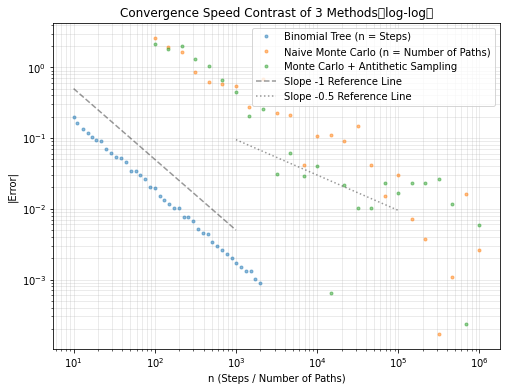

In [12]:
import matplotlib.pyplot as plt

# Basic Parameters
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2
true_price = bs_price(S, K, T, r, sigma, "call")

# ---- Binomial Tree Convergence ----
tree_ns = np.unique(np.logspace(1, 3.3, 40).astype(int))  # 10~2000，40 points
tree_errors = [abs(binomial_price(S, K, T, r, sigma, n) - true_price) for n in tree_ns]

# ---- Monte Carlo Convergence（Naive vs Antithetic Sampling）----
mc_ns = np.unique(np.logspace(2, 6, 25).astype(int))  # 100 到 1,000,000

mc_errors = []
mc_anti_errors = []
for n in mc_ns:
    p, _ = mc_price(S, K, T, r, sigma, n_paths=n, seed=42)
    p_anti, _ = mc_price(S, K, T, r, sigma, n_paths=n, seed=42, antithetic=True)
    mc_errors.append(abs(p - true_price))
    mc_anti_errors.append(abs(p_anti - true_price))

# ---- Graph ----
plt.figure(figsize=(8, 6))
plt.loglog(tree_ns, tree_errors, '.', alpha=0.5, label="Binomial Tree (n = Steps)")
plt.loglog(mc_ns, mc_errors, '.', alpha=0.5, label="Naive Monte Carlo (n = Number of Paths)")
plt.loglog(mc_ns, mc_anti_errors, '.', alpha=0.5, label="Monte Carlo + Antithetic Sampling")

# Reference Line
ref_n = np.array([10, 1000])
plt.loglog(ref_n, 5 / ref_n, 'k--', alpha=0.4, label="Slope -1 Reference Line")
plt.loglog(ref_n * 100, 3 / np.sqrt(ref_n * 100), 'k:', alpha=0.4, label="Slope -0.5 Reference Line")

plt.xlabel("n (Steps / Number of Paths)")
plt.ylabel("|Error|")
plt.title("Convergence Speed Contrast of 3 Methods（log-log）")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("convergence.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Use intervels with more stability to fit slope
log_n = np.log(tree_ns[10:])
log_err = np.log(tree_errors[10:])
slope, intercept = np.polyfit(log_n, log_err, 1)
print(f"Binomial Tree Empirical Order of Convergence: {slope:.2f}  (Theoretical value close to -1)")

log_n_mc = np.log(mc_ns)
log_err_mc = np.log(mc_errors)
slope_mc, _ = np.polyfit(log_n_mc, log_err_mc, 1)
print(f"Monte Carlo Empirical Order of Convergence: {slope_mc:.2f}  (Theoretical value close to -0.5)")

Binomial Tree Empirical Order of Convergence: -1.02  (Theoretical value close to -1)
Monte Carlo Empirical Order of Convergence: -0.81  (Theoretical value close to -0.5)


In [14]:
def mc_rmse(S, K, T, r, sigma, n_paths, true_price, n_repeats=30, antithetic=False):
    errors = []
    for i in range(n_repeats):
        p, _ = mc_price(S, K, T, r, sigma, n_paths, seed=i, antithetic=antithetic)
        errors.append(p - true_price)
    errors = np.array(errors)
    return np.sqrt(np.mean(errors**2))  # RMSE

mc_ns = np.unique(np.logspace(2, 6, 20).astype(int))
mc_rmses = [mc_rmse(S, K, T, r, sigma, n, true_price) for n in mc_ns]
mc_anti_rmses = [mc_rmse(S, K, T, r, sigma, n, true_price, antithetic=True) for n in mc_ns]

In [15]:
log_n_mc = np.log(mc_ns)
log_rmse_mc = np.log(mc_rmses)
slope_mc, _ = np.polyfit(log_n_mc, log_rmse_mc, 1)
print(f"Monte Carlo Empirical Order of Convergence(RMSE): {slope_mc:.2f}  (Theoretical value close to -0.5)")

Monte Carlo Empirical Order of Convergence(RMSE): -0.52  (Theoretical value close to -0.5)


In [16]:
def bs_greeks(S, K, T, r, sigma, option="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    pdf_d1 = norm.pdf(d1)  

    if option == "call":
        delta = norm.cdf(d1)
        theta = (-S * pdf_d1 * sigma / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * norm.cdf(d2))
        rho = K * T * np.exp(-r * T) * norm.cdf(d2)
    else:
        delta = norm.cdf(d1) - 1
        theta = (-S * pdf_d1 * sigma / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * norm.cdf(-d2))
        rho = -K * T * np.exp(-r * T) * norm.cdf(-d2)

    gamma = pdf_d1 / (S * sigma * np.sqrt(T))   # call&put have same gamma
    vega = S * pdf_d1 * np.sqrt(T)              # call&put have same vega

    return {"delta": delta, "gamma": gamma, "vega": vega,
            "theta": theta, "rho": rho}

In [17]:
def fd_greeks(pricer, S, K, T, r, sigma, option="call", h=1e-4):
    def V(S_, T_, r_, sigma_):
        return pricer(S_, K, T_, r_, sigma_, option)

    delta = (V(S + h, T, r, sigma) - V(S - h, T, r, sigma)) / (2 * h)
    gamma = (V(S + h, T, r, sigma) - 2 * V(S, T, r, sigma)
              + V(S - h, T, r, sigma)) / (h ** 2)
    vega = (V(S, T, r, sigma + h) - V(S, T, r, sigma - h)) / (2 * h)
    theta = -(V(S, T + h, r, sigma) - V(S, T - h, r, sigma)) / (2 * h)
    rho = (V(S, T, r + h, sigma) - V(S, T, r - h, sigma)) / (2 * h)

    return {"delta": delta, "gamma": gamma, "vega": vega,
            "theta": theta, "rho": rho}

In [18]:
S, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

greeks_analytic = bs_greeks(S, K, T, r, sigma, "call")
greeks_fd = fd_greeks(bs_price, S, K, T, r, sigma, "call", h=1e-4)

for g in greeks_analytic:
    print(f"{g:6s}  analytic={greeks_analytic[g]:.6f}  fd={greeks_fd[g]:.6f}  "
          f"diff={abs(greeks_analytic[g]-greeks_fd[g]):.2e}")

delta   analytic=0.636831  fd=0.636831  diff=6.08e-12
gamma   analytic=0.018762  fd=0.018762  diff=1.36e-07
vega    analytic=37.524035  fd=37.524034  diff=3.04e-07
theta   analytic=-6.414028  fd=-6.414028  diff=4.92e-09
rho     analytic=53.232482  fd=53.232481  diff=7.71e-07


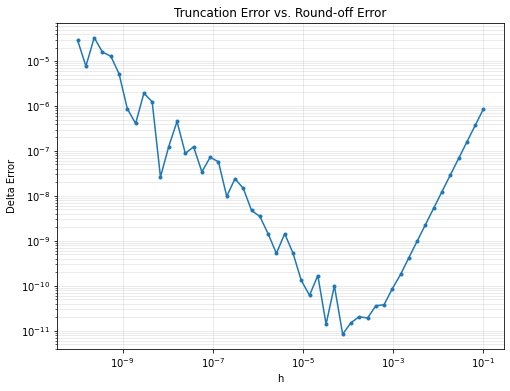

In [19]:
hs = np.logspace(-10, -1, 50)
delta_errors = []

for h in hs:
    fd = fd_greeks(bs_price, S, K, T, r, sigma, "call", h=h)
    delta_errors.append(abs(fd["delta"] - greeks_analytic["delta"]))

plt.figure(figsize=(8, 6))
plt.loglog(hs, delta_errors, '.-')
plt.xlabel("h")
plt.ylabel("Delta Error")
plt.title("Truncation Error vs. Round-off Error")
plt.grid(True, which="both", alpha=0.3)
plt.savefig("fd_stepsize.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# Greeks for Binomial Tree
greeks_tree = fd_greeks(lambda S,K,T,r,sigma,opt: binomial_price(S,K,T,r,sigma,n=500,option=opt),
                         S, K, T, r, sigma, "call", h=1e-3)

print("Binomial Tree(Finite Difference) vs BS(Analytics):")
for g in greeks_analytic:
    print(f"{g:6s}  tree_fd={greeks_tree[g]:.6f}  bs_analytic={greeks_analytic[g]:.6f}")

Binomial Tree(Finite Difference) vs BS(Analytics):
delta   tree_fd=0.636767  bs_analytic=0.636831
gamma   tree_fd=33.545682  bs_analytic=0.018762
vega    tree_fd=37.505182  bs_analytic=37.524035
theta   tree_fd=-6.412027  bs_analytic=-6.414028
rho     tree_fd=53.230023  bs_analytic=53.232482


In [21]:
# Solution 1：For gamma, use larger h
def fd_gamma_only(pricer, S, K, T, r, sigma, option="call", h=1.0):
    def V(S_): return pricer(S_, K, T, r, sigma, option)
    return (V(S+h) - 2*V(S) + V(S-h)) / h**2

for h in [1e-3, 1e-2, 0.1, 0.5, 1.0, 2.0]:
    g = fd_gamma_only(lambda S,K,T,r,sigma,opt: binomial_price(S,K,T,r,sigma,n=500,option=opt),
                       S, K, T, r, sigma, "call", h=h)
    print(f"h={h:6.3f}  tree_gamma={g:.6f}")
print(f"bs_gamma = {greeks_analytic['gamma']:.6f}")

# Solution 2：Increase step n
for n in [100, 500, 2000, 5000]:
    g = fd_gamma_only(lambda S,K,T,r,sigma,opt: binomial_price(S,K,T,r,sigma,n=n,option=opt),
                       S, K, T, r, sigma, "call", h=0.5)
    print(f"n={n:6d}  tree_gamma={g:.6f}")

h= 0.001  tree_gamma=33.545682
h= 0.010  tree_gamma=3.354568
h= 0.100  tree_gamma=0.335457
h= 0.500  tree_gamma=0.067091
h= 1.000  tree_gamma=0.033546
h= 2.000  tree_gamma=0.020309
bs_gamma = 0.018762
n=   100  tree_gamma=0.149720
n=   500  tree_gamma=0.067091
n=  2000  tree_gamma=0.033558
n=  5000  tree_gamma=0.021226


In [22]:
# Replace ATM option, use DITM option
S, K2, T, r, sigma = 100, 70, 1, 0.05, 0.2
bs_g = bs_greeks(S, K2, T, r, sigma, "call")["gamma"]

for h in [0.1, 0.5, 1.0, 2.0]:
    g = fd_gamma_only(lambda S,K,T,r,sigma,opt: binomial_price(S,K,T,r,sigma,n=500,option=opt),
                       S, K2, T, r, sigma, "call", h=h)
    print(f"h={h}  tree_gamma={g:.6f}")
print(f"bs_gamma={bs_g:.6f}")

h=0.1  tree_gamma=-0.000000
h=0.5  tree_gamma=0.005662
h=1.0  tree_gamma=0.003229
h=2.0  tree_gamma=0.002142
bs_gamma=0.002049


In [23]:
def fd_gamma_adaptive(pricer_fn, S, K, T, r, sigma, n, option="call"):
    dt = T / n
    node_spacing = S * sigma * np.sqrt(dt)  
    h = max(node_spacing * 3, 0.01)  
    def V(S_): return pricer_fn(S_, K, T, r, sigma, option)
    return (V(S+h) - 2*V(S) + V(S-h)) / h**2, h

for n in [500, 2000, 5000, 20000]:
    g, h_used = fd_gamma_adaptive(
        lambda S,K,T,r,sigma,opt: binomial_price(S,K,T,r,sigma,n=n,option=opt),
        S, K, T, r, sigma, n, "call")
    print(f"n={n:6d}  h_used={h_used:.4f}  tree_gamma={g:.6f}")
print(f"bs_gamma={greeks_analytic['gamma']:.6f}")

n=   500  h_used=2.6833  tree_gamma=0.020811
n=  2000  h_used=1.3416  tree_gamma=0.020838
n=  5000  h_used=0.8485  tree_gamma=0.020843
n= 20000  h_used=0.4243  tree_gamma=0.020846
bs_gamma=0.018762


In [24]:
def delta_hedge_simulation(S0, K, T, r, sigma, n_rebalance, n_paths, seed=None):
    rng = np.random.default_rng(seed)
    dt = T / n_rebalance

    # Random number for all steps and all paths
    Z = rng.standard_normal((n_paths, n_rebalance))

    # Generate stock price path
    S = np.full(n_paths, S0, dtype=float)

    # t=0: sell option, earn option price, buy delta stock to hedge
    option_premium = bs_price(S0, K, T, r, sigma, "call")
    time_remaining = T
    delta = bs_greeks(S0, K, time_remaining, r, sigma, "call")["delta"]
    delta = np.full(n_paths, delta)

    cash = option_premium - delta * S0  

    for step in range(n_rebalance):
        # Stock price 1 step further(use GBM)
        S = S * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, step])
        time_remaining -= dt
        time_remaining = max(time_remaining, 1e-8)  

        # Cash account uses risk free rate to earn interest
        cash = cash * np.exp(r * dt)

        if step < n_rebalance - 1:
            # Calculate delta to adjust position
            new_delta = bs_greeks(S, K, time_remaining, r, sigma, "call")["delta"]
            cash = cash - (new_delta - delta) * S  
            delta = new_delta

    # Expiratioin date：Sell stock to pay option payoff
    payoff = np.maximum(S - K, 0)
    final_pnl = cash + delta * S - payoff

    return final_pnl

In [25]:
S0, K, T, r, sigma = 100, 100, 1, 0.05, 0.2

pnl = delta_hedge_simulation(S0, K, T, r, sigma, n_rebalance=50, n_paths=50000, seed=1)
print(f"Mean: {pnl.mean():.4f}   StdErr: {pnl.std():.4f}")

Mean: 0.0096   StdErr: 0.9699


n_rebalance=   1   std(PnL)=5.9389
n_rebalance=   2   std(PnL)=4.3855
n_rebalance=   4   std(PnL)=3.2462
n_rebalance=  13   std(PnL)=1.8670
n_rebalance=  26   std(PnL)=1.3241
n_rebalance=  52   std(PnL)=0.9477
n_rebalance= 100   std(PnL)=0.6893
n_rebalance= 252   std(PnL)=0.4387
n_rebalance= 500   std(PnL)=0.3109


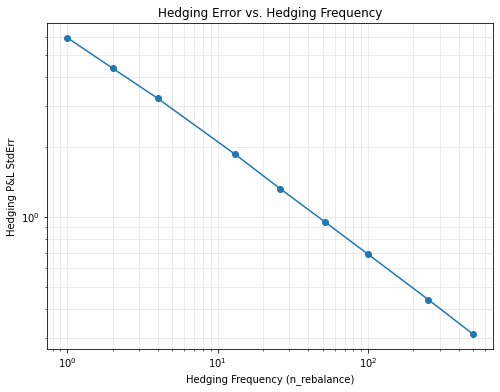

Empirical Slope: -0.48  (Theoretical value should be close to -0.5)


In [26]:
rebalance_counts = [1, 2, 4, 13, 26, 52, 100, 252, 500]  
pnl_stds = []

for n_reb in rebalance_counts:
    pnl = delta_hedge_simulation(S0, K, T, r, sigma, n_reb, n_paths=50000, seed=1)
    pnl_stds.append(pnl.std())
    print(f"n_rebalance={n_reb:4d}   std(PnL)={pnl.std():.4f}")

plt.figure(figsize=(8,6))
plt.loglog(rebalance_counts, pnl_stds, 'o-')
plt.xlabel("Hedging Frequency (n_rebalance)")
plt.ylabel("Hedging P&L StdErr")
plt.title("Hedging Error vs. Hedging Frequency")
plt.grid(True, which="both", alpha=0.3)
plt.savefig("hedging_error.png", dpi=150, bbox_inches="tight")
plt.show()

slope, _ = np.polyfit(np.log(rebalance_counts), np.log(pnl_stds), 1)
print(f"Empirical Slope: {slope:.2f}  (Theoretical value should be close to -0.5)")

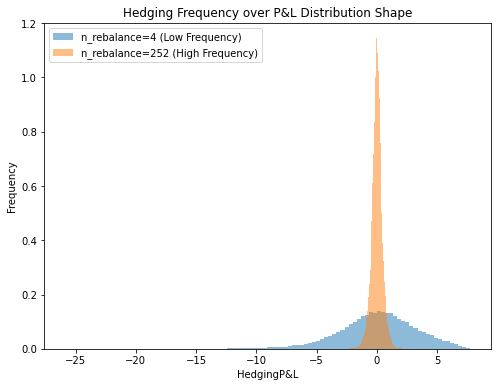

In [27]:
pnl_low = delta_hedge_simulation(S0, K, T, r, sigma, n_rebalance=4, n_paths=50000, seed=1)
pnl_high = delta_hedge_simulation(S0, K, T, r, sigma, n_rebalance=252, n_paths=50000, seed=1)

plt.figure(figsize=(8,6))
plt.hist(pnl_low, bins=100, alpha=0.5, density=True, label="n_rebalance=4 (Low Frequency)")
plt.hist(pnl_high, bins=100, alpha=0.5, density=True, label="n_rebalance=252 (High Frequency)")
plt.xlabel("HedgingP&L")
plt.ylabel("Frequency")
plt.title("Hedging Frequency over P&L Distribution Shape")
plt.legend()
plt.savefig("pnl_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [28]:
# ATM Option vs. DOTM Option Hedging Error
K_atm = 100
K_otm = 130 

pnl_atm = delta_hedge_simulation(S0, K_atm, T, r, sigma, n_rebalance=52, n_paths=50000, seed=1)
pnl_otm = delta_hedge_simulation(S0, K_otm, T, r, sigma, n_rebalance=52, n_paths=50000, seed=1)

gamma_atm = bs_greeks(S0, K_atm, T, r, sigma)["gamma"]
gamma_otm = bs_greeks(S0, K_otm, T, r, sigma)["gamma"]

print(f"ATM(K={K_atm}):  gamma={gamma_atm:.4f}  std(PnL)={pnl_atm.std():.4f}")
print(f"OTM(K={K_otm}):  gamma={gamma_otm:.4f}  std(PnL)={pnl_otm.std():.4f}")

ATM(K=100):  gamma=0.0188  std(PnL)=0.9477
OTM(K=130):  gamma=0.0126  std(PnL)=0.8107


In [30]:
def delta_hedge_vol_mismatch(S0, K, T, r, sigma_pricing, sigma_real, n_rebalance, n_paths, seed=None):
    rng = np.random.default_rng(seed)
    dt = T / n_rebalance
    Z = rng.standard_normal((n_paths, n_rebalance))
    S = np.full(n_paths, S0, dtype=float)

    option_premium = bs_price(S0, K, T, r, sigma_pricing, "call")  # premium using pricing volatility
    time_remaining = T
    delta = np.full(n_paths, bs_greeks(S0, K, time_remaining, r, sigma_pricing, "call")["delta"])
    cash = option_premium - delta * S0

    for step in range(n_rebalance):
        # Stock price evolves with real volatility, instead of the one when pricing
        S = S * np.exp((r - 0.5*sigma_real**2)*dt + sigma_real*np.sqrt(dt)*Z[:, step])
        time_remaining = max(time_remaining - dt, 1e-8)
        cash = cash * np.exp(r * dt)
        if step < n_rebalance - 1:
            new_delta = bs_greeks(S, K, time_remaining, r, sigma_pricing, "call")["delta"]  # delta using pricing volatility
            cash = cash - (new_delta - delta) * S
            delta = new_delta

    payoff = np.maximum(S - K, 0)
    return cash + delta * S - payoff

# Real vol > Pricing vol：Option is sold with lower price
pnl_under = delta_hedge_vol_mismatch(S0, K, T, r, sigma_pricing=0.2, sigma_real=0.3, n_rebalance=52, n_paths=50000, seed=1)
# Real vol > Pricing vol：Option is sold with higher price
pnl_over = delta_hedge_vol_mismatch(S0, K, T, r, sigma_pricing=0.2, sigma_real=0.1, n_rebalance=52, n_paths=50000, seed=1)

print(f"Real vol(30%) > Pricing vol(20%): Mean P&L = {pnl_under.mean():.4f}  (Negative expectation, systemic loss)")
print(f"Real vol(10%) < Pricing vol(20%): Mean P&L = {pnl_over.mean():.4f}  (Positive expectation, systemic profit)")

Real vol(30%) > Pricing vol(20%): Mean P&L = -3.9842  (Negative expectation, systemic loss)
Real vol(10%) < Pricing vol(20%): Mean P&L = 3.8337  (Positive expectation, systemic profit)


In [31]:
def delta_hedge_with_cost(S0, K, T, r, sigma, n_rebalance, n_paths, cost_rate=0.001, seed=None):
    rng = np.random.default_rng(seed)
    dt = T / n_rebalance
    Z = rng.standard_normal((n_paths, n_rebalance))
    S = np.full(n_paths, S0, dtype=float)

    option_premium = bs_price(S0, K, T, r, sigma, "call")
    time_remaining = T
    delta = np.full(n_paths, bs_greeks(S0, K, time_remaining, r, sigma, "call")["delta"])

    # Open a Position needs transaction cost
    initial_cost = cost_rate * np.abs(delta * S0)
    cash = option_premium - delta * S0 - initial_cost

    for step in range(n_rebalance):
        S = S * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[:, step])
        time_remaining = max(time_remaining - dt, 1e-8)
        cash = cash * np.exp(r * dt)

        if step < n_rebalance - 1:
            new_delta = bs_greeks(S, K, time_remaining, r, sigma, "call")["delta"]
            trade_amount = (new_delta - delta) * S       
            cost = cost_rate * np.abs(trade_amount)        # Transaction cost is paid by percentage
            cash = cash - trade_amount - cost              
            delta = new_delta

    payoff = np.maximum(S - K, 0)
    final_pnl = cash + delta * S - payoff
    return final_pnl

In [32]:
rebalance_counts = [1, 2, 4, 13, 26, 52, 100, 252, 500]
cost_rate = 0.001  

results = []
for n_reb in rebalance_counts:
    pnl_no_cost = delta_hedge_simulation(S0, K, T, r, sigma, n_reb, n_paths=50000, seed=1)
    pnl_with_cost = delta_hedge_with_cost(S0, K, T, r, sigma, n_reb, n_paths=50000, cost_rate=cost_rate, seed=1)
    results.append({
        "n": n_reb,
        "std_no_cost": pnl_no_cost.std(),
        "mean_with_cost": pnl_with_cost.mean(),
        "std_with_cost": pnl_with_cost.std(),
    })
    print(f"n={n_reb:4d}  No cost_std={pnl_no_cost.std():.4f}  "
          f"With cost mean={pnl_with_cost.mean():.4f}  With cost std={pnl_with_cost.std():.4f}")

n=   1  No cost_std=5.9389  With cost mean=-0.0317  With cost std=5.9389
n=   2  No cost_std=4.3855  With cost mean=-0.0549  With cost std=4.3934
n=   4  No cost_std=3.2462  With cost mean=-0.1104  With cost std=3.2560
n=  13  No cost_std=1.8670  With cost mean=-0.1693  With cost std=1.8777
n=  26  No cost_std=1.3241  With cost mean=-0.2140  With cost std=1.3354
n=  52  No cost_std=0.9477  With cost mean=-0.2891  With cost std=0.9615
n= 100  No cost_std=0.6893  With cost mean=-0.3804  With cost std=0.7092
n= 252  No cost_std=0.4387  With cost mean=-0.5656  With cost std=0.4885
n= 500  No cost_std=0.3109  With cost mean=-0.7691  With cost std=0.4186


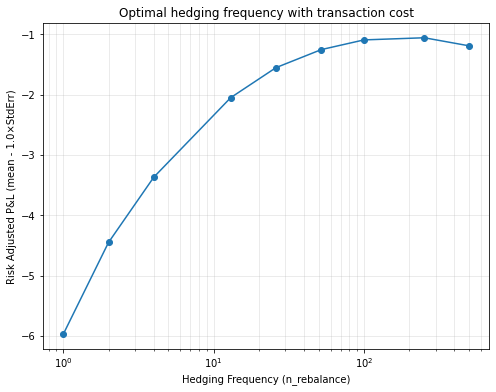

In [33]:
k = 1.0  # Risk Aversion Coefficient
risk_adjusted = [r["mean_with_cost"] - k * r["std_with_cost"] for r in results]

plt.figure(figsize=(8,6))
plt.plot([r["n"] for r in results], risk_adjusted, 'o-')
plt.xscale("log")
plt.xlabel("Hedging Frequency (n_rebalance)")
plt.ylabel(f"Risk Adjusted P&L (mean - {k}×StdErr)")
plt.title("Optimal hedging frequency with transaction cost")
plt.grid(True, which="both", alpha=0.3)
plt.savefig("optimal_hedge_freq.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
# Method 1
for cost_rate in [0.001, 0.005, 0.01]:
    print(f"\n=== cost_rate = {cost_rate} ===")
    results = []
    for n_reb in rebalance_counts:
        pnl = delta_hedge_with_cost(S0, K, T, r, sigma, n_reb, n_paths=50000, cost_rate=cost_rate, seed=1)
        results.append({"n": n_reb, "mean": pnl.mean(), "std": pnl.std()})
        print(f"n={n_reb:4d}  mean={pnl.mean():.4f}  std={pnl.std():.4f}")


=== cost_rate = 0.001 ===
n=   1  mean=-0.0317  std=5.9389
n=   2  mean=-0.0549  std=4.3934
n=   4  mean=-0.1104  std=3.2560
n=  13  mean=-0.1693  std=1.8777
n=  26  mean=-0.2140  std=1.3354
n=  52  mean=-0.2891  std=0.9615
n= 100  mean=-0.3804  std=0.7092
n= 252  mean=-0.5656  std=0.4885
n= 500  mean=-0.7691  std=0.4186

=== cost_rate = 0.005 ===
n=   1  mean=-0.2995  std=5.9389
n=   2  mean=-0.4207  std=4.4252
n=   4  mean=-0.5795  std=3.2959
n=  13  mean=-0.8678  std=1.9270
n=  26  mean=-1.1068  std=1.4026
n=  52  mean=-1.4579  std=1.0814
n= 100  mean=-1.9004  std=0.9454
n= 252  mean=-2.8286  std=1.0734
n= 500  mean=-3.8492  std=1.3921

=== cost_rate = 0.01 ===
n=   1  mean=-0.6342  std=5.9389
n=   2  mean=-0.8781  std=4.4656
n=   4  mean=-1.1660  std=3.3472
n=  13  mean=-1.7409  std=2.0024
n=  26  mean=-2.2228  std=1.5299
n=  52  mean=-2.9189  std=1.3373
n= 100  mean=-3.8003  std=1.4181
n= 252  mean=-5.6574  std=1.9836
n= 500  mean=-7.6993  std=2.7204


In [35]:
rebalance_counts_extended = [1, 2, 4, 13, 26, 52, 100, 252, 500, 1000, 2000, 5000]

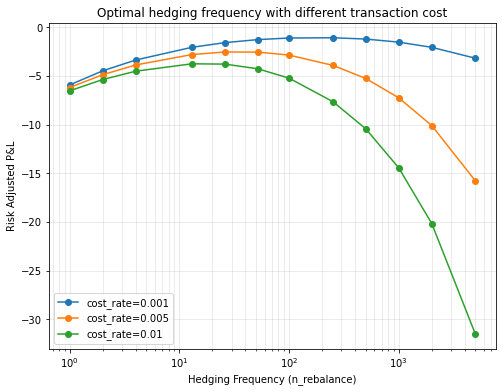

In [36]:
plt.figure(figsize=(8,6))
for cost_rate in [0.001, 0.005, 0.01]:
    risk_adj = []
    for n_reb in rebalance_counts_extended:
        pnl = delta_hedge_with_cost(S0, K, T, r, sigma, n_reb, n_paths=30000, cost_rate=cost_rate, seed=1)
        risk_adj.append(pnl.mean() - 1.0 * pnl.std())
    plt.plot(rebalance_counts_extended, risk_adj, 'o-', label=f"cost_rate={cost_rate}")

plt.xscale("log")
plt.xlabel("Hedging Frequency (n_rebalance)")
plt.ylabel("Risk Adjusted P&L")
plt.title("Optimal hedging frequency with different transaction cost")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.savefig("optimal_hedge_freq_multi.png", dpi=150, bbox_inches="tight")
plt.show()